# Naive Bayes Classifier
## Dataset: Data Bantal
Notebook ini membangun model Naive Bayes (Gaussian NB) untuk memprediksi apakah konsumen menyukai produk bantal premium berdasarkan fitur demografi dan preferensi.

In [1]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

## 1. Load Dataset

In [2]:
df = pd.read_csv('../dataset/data_bantal.csv')
df

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
0,INSERT INTO data_preferensi (nama,jenis_kelamin,usia,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN
1,('Kece Series','P',23,4,3,1,10,0,1,1,2,'Direkomendasikan'),
2,('Kece Series','L',26,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN
3,('Premium Series','P',22,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN
4,('Kece Series','P',45,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,('Kids Signature Series','P',55,2,5,2,5,0,1,0,1,'Cukup Direkomendasikan'),NaN
297,('Signature Series','L',52,4,4,5,10,0,0,0,3,'Cukup Direkomendasikan'),NaN
298,('Kece Series','L',46,5,1,4,5,1,0,0,3,'Cukup Direkomendasikan'),NaN
299,('Deluxe Series','P',54,5,2,2,7,1,1,0,2,'Direkomendasikan'),NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              301 non-null    object
 1   Nama Product    301 non-null    object
 2   Jenis Kelamin   301 non-null    object
 3   Usia            301 non-null    object
 4   Harga           301 non-null    object
 5   Desain          301 non-null    object
 6   Kenyamanan      301 non-null    object
 7   Durasi Tidur    301 non-null    object
 8   Random Forest   301 non-null    object
 9   Grad. Boosting  301 non-null    object
 10  Naive Bayes     301 non-null    object
 11  K-Means         301 non-null    object
 12  Kesimpulan      1 non-null      object
dtypes: object(13)
memory usage: 30.7+ KB


## 2. Preprocessing & Feature Engineering

In [4]:
# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Encode kolom kategori
le = LabelEncoder()
df['Jenis Kelamin'] = le.fit_transform(df['Jenis Kelamin'])

# Pastikan kolom numerik aman
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce')
df['Desain'] = pd.to_numeric(df['Desain'], errors='coerce')
df['Kenyamanan'] = pd.to_numeric(df['Kenyamanan'], errors='coerce')

# Isi missing value
df = df.fillna(0)

# Target: suka produk premium jika Harga + Desain + Kenyamanan >= 12
df['suka_premium'] = (
    (df['Harga'] + df['Desain'] + df['Kenyamanan']) >= 12
).astype(int)

df['suka_premium'].value_counts()

suka_premium
1    196
0    105
Name: count, dtype: int64

## 3. Fitur dan Target

In [5]:
X = df[['Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']]
y = df['suka_premium']

# Bersihkan data agar jadi angka semua
X = X.apply(lambda col: col.astype(str).str.strip())
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

print("Shape X:", X.shape)
print("Distribusi y:", y.value_counts().to_dict())

Shape X: (301, 6)
Distribusi y: {1: 196, 0: 105}


## 4. Split Data

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (240, 6), Test: (61, 6)


## 5. Training Model Naive Bayes

In [7]:
nb_clf = GaussianNB()
nb_clf.fit(x_train, y_train)

print("✅ Naive Bayes berhasil dilatih!")

✅ Naive Bayes berhasil dilatih!


## 6. Prediksi

In [8]:
y_predict = nb_clf.predict(x_test)
y_predict

array([1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1])

## 7. Evaluasi Model

Test Accuracy: 0.9508196721311475

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       1.00      0.93      0.96        44

    accuracy                           0.95        61
   macro avg       0.93      0.97      0.94        61
weighted avg       0.96      0.95      0.95        61



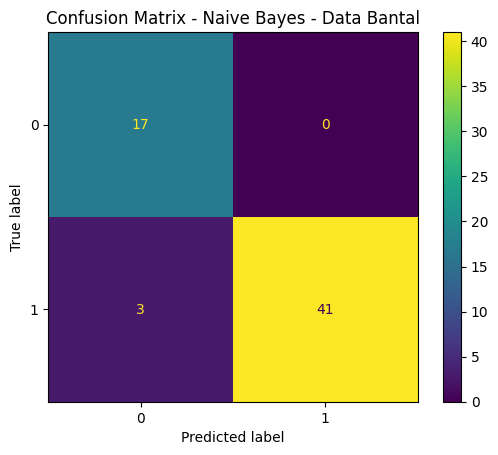

In [9]:
print('Test Accuracy:', metrics.accuracy_score(y_test, y_predict))
print()
print(metrics.classification_report(y_test, y_predict))

ConfusionMatrixDisplay.from_predictions(y_test, y_predict)
plt.title('Confusion Matrix - Naive Bayes - Data Bantal')
plt.show()

## 8. Prediksi Data Baru

In [10]:
# [jenis_kelamin(0=L,1=P), usia, harga, desain, kenyamanan, durasi_tidur]
data_baru = [
    [0, 18, 4, 5, 5, 7],
    [1, 23, 5, 5, 5, 8],
    [0, 22, 3, 3, 4, 6],
    [1, 27, 5, 5, 5, 8],
    [0, 26, 3, 4, 4, 6]
]

predict_data = nb_clf.predict(data_baru)
print('Hasil Prediksi:', predict_data)

for i, (inp, pred) in enumerate(zip(data_baru, predict_data)):
    status = 'Menyukai Premium' if pred == 1 else 'Tidak Menyukai Premium'
    print(f'  Data {i+1}: {status}')

Hasil Prediksi: [1 0 0 0 0]
  Data 1: Menyukai Premium
  Data 2: Tidak Menyukai Premium
  Data 3: Tidak Menyukai Premium
  Data 4: Tidak Menyukai Premium
  Data 5: Tidak Menyukai Premium


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


## 9. Simpan Model

In [11]:
import pickle

with open('../flask-app/nb_model.pkl', 'wb') as file:
    pickle.dump(nb_clf, file)

print('✅ Model Naive Bayes berhasil disimpan ke nb_model.pkl')

✅ Model Naive Bayes berhasil disimpan ke nb_model.pkl
